In [205]:
import pandas as pd
import numpy as np

In [206]:
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [207]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [209]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [210]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [211]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

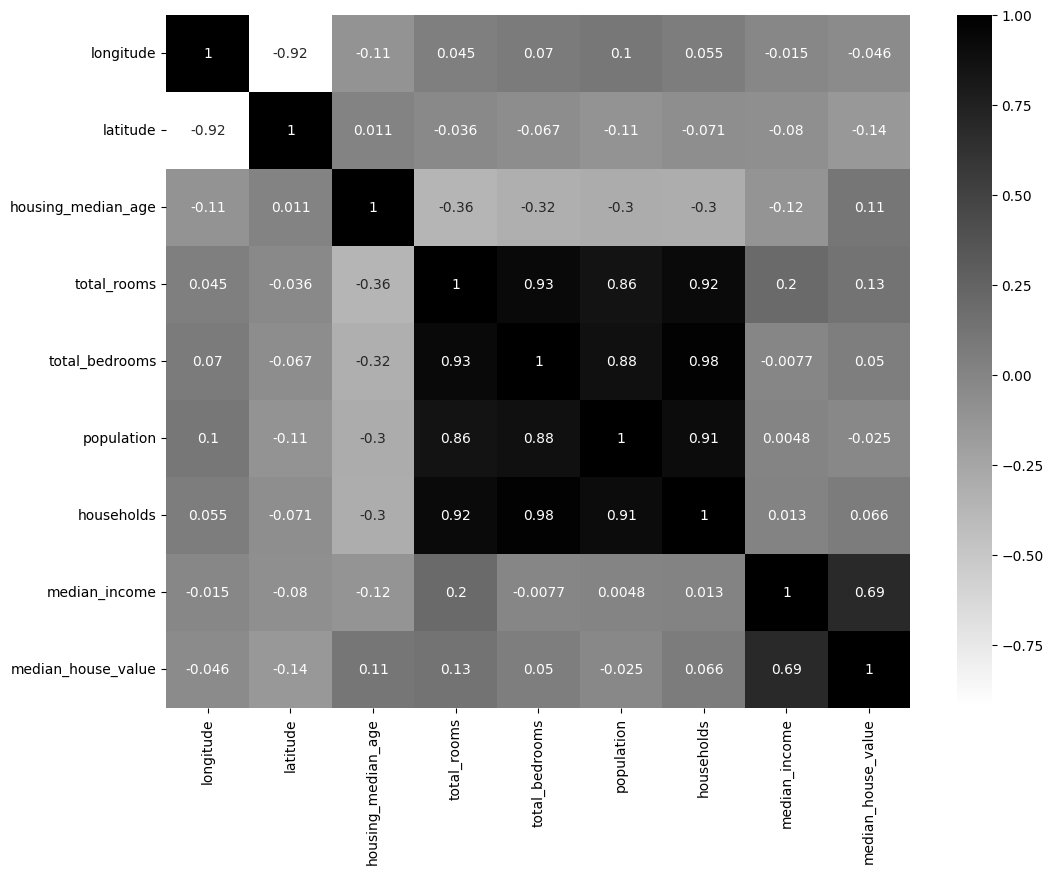

In [213]:
plt.figure(figsize=(12,9))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='binary')

<Axes: xlabel='median_income', ylabel='median_house_value'>

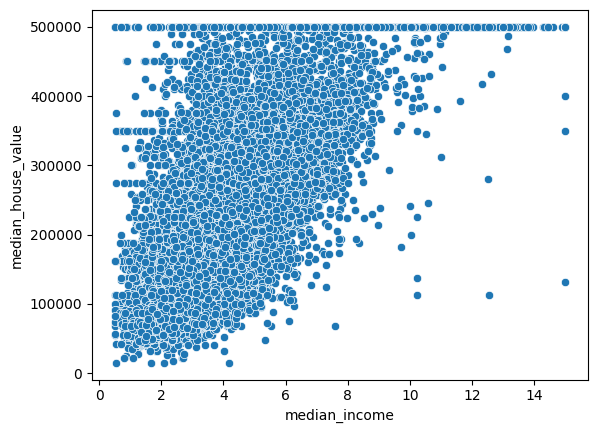

In [214]:
sns.scatterplot(x=df['median_income'], y=df['median_house_value'])

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

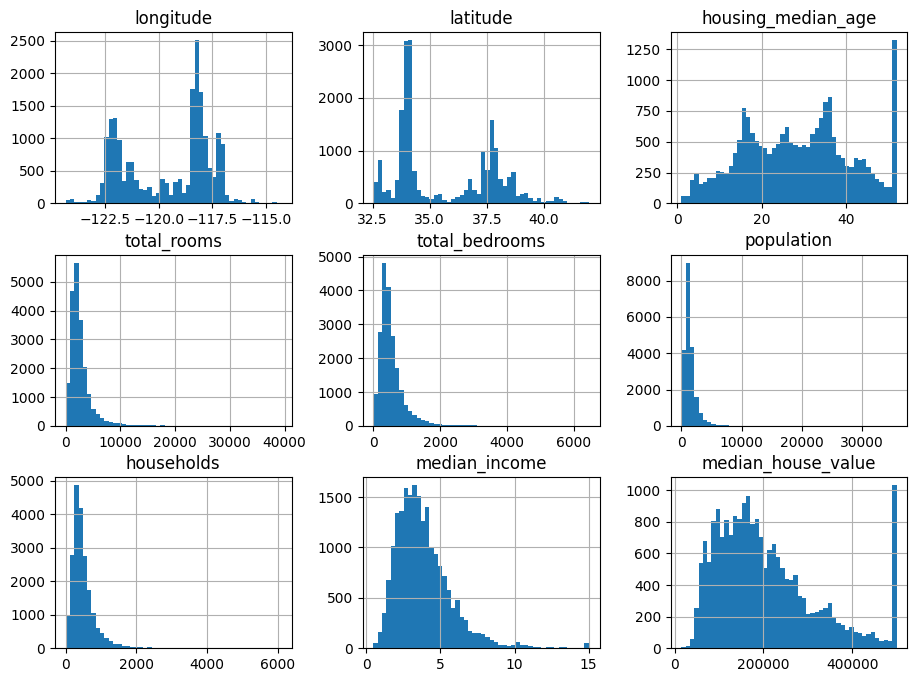

In [215]:
df.hist(figsize=(11,8), bins=50)

In [238]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [239]:
num_cols = ['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','population','households','median_income']
ord_col = ['ocean_proximity']
order = [['INLAND','<1H OCEAN', 'NEAR OCEAN', 'NEAR BAY','ISLAND']]

In [240]:
x = df.drop(columns='median_house_value')
y = df.iloc[:,8]

In [241]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

In [242]:
def add_cols(arr):
    bedrooms_per_household = arr[:, [4]] / arr[: , [6]]
    rooms_per_household = arr[:, [3]] / arr[: , [6]]
    population_per_household = arr[:, [5]] / arr[: , [6]]

    return np.c_[arr, rooms_per_household, bedrooms_per_household, population_per_household]

In [243]:
num_pipe = Pipeline( steps= [
    ('imputing', SimpleImputer(strategy='median')),
    ('add_cols', FunctionTransformer(add_cols)),
    ('standardize', StandardScaler())
])

ord_pipe = Pipeline( steps= [
    ('ordinal', OrdinalEncoder(categories=order))
])

In [244]:
transformation = ColumnTransformer( transformers= [
    ('Num data processing', num_pipe, num_cols),
    ('Categorical data processing', ord_pipe, ord_col)
], remainder='passthrough')

In [250]:
model = Pipeline( steps= [
    ('Pipe1',transformation),
    ('Pipe2',XGBRegressor(colsample_bytree = 0.6, gamma = 0, learning_rate = 0.05, max_depth = 7, n_estimators = 500))
])

In [251]:
model.fit(x_train, y_train)

,steps,"[('Pipe1', ...), ('Pipe2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Num data processing', ...), ('Categorical data processing', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [253]:
y_pred = model.predict(x_test)

In [254]:
r2_score(y_test, y_pred)

0.8501087658157648

In [233]:
param_grid = {
    'Pipe2__n_estimators': [100, 500, 1000],
    'Pipe2__learning_rate': [0.01, 0.05, 0.1],
    'Pipe2__max_depth': [3, 5, 7],
    'Pipe2__colsample_bytree': [0.6, 0.8, 1.0],
    'Pipe2__gamma': [0, 0.1, 0.2],
}

grid = GridSearchCV(model, param_grid , cv=5, n_jobs=-1)
grid.fit(x_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'Pipe2__colsample_bytree': [0.6, 0.8, ...], 'Pipe2__gamma': [0, 0.1, ...], 'Pipe2__learning_rate': [0.01, 0.05, ...], 'Pipe2__max_depth': [3, 5, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Num data processing', ...), ('Categorical data processing', ...)]"


In [234]:
grid.best_score_

np.float64(0.848043000278491)

In [236]:
grid.best_params_

{'Pipe2__colsample_bytree': 0.6,
 'Pipe2__gamma': 0,
 'Pipe2__learning_rate': 0.05,
 'Pipe2__max_depth': 7,
 'Pipe2__n_estimators': 1000}

In [259]:
import joblib
import gradio as gr

joblib.dump(model, 'California_dataset_house_price_predictor.pkl')

['California_dataset_house_price_predictor.pkl']

In [269]:
m = joblib.load('California_dataset_house_price_predictor.pkl')

def predict(long, lat, h_m_a, t_rms, t_bdrms, p, hlds, m_i, o_p):
    frame = pd.DataFrame([[long, lat, h_m_a, t_rms, t_bdrms, p, hlds, m_i, o_p]],
                        columns=['longitude', 'latitude', 'housing_median_age', 'total_rooms', 
                                 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity'])
    prediction = m.predict(frame)[0]
    return f"Estimated Value : ${prediction}"

demo = gr.Interface(
    fn=predict,
    inputs = [
        gr.Slider(-124.350000, -114.310000, label='Longitude'),
        gr.Slider(32.540000, 41.950000, label='Latitude'),
        gr.Number(label='Housing Median Age'),
        gr.Number(label='Total Rooms'),
        gr.Number(label='Total Bedrooms'),
        gr.Number(label='Population'),
        gr.Number(label='Households'),
        gr.Number(label='Median Income'),
        gr.Dropdown(['<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'NEAR BAY', 'ISLAND'], label='Proximity')
    ],
    outputs='text',
    title='California House Price Predictor'
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [276]:
df.sample()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
1032,-120.8,38.51,23.0,1001.0,195.0,369.0,157.0,3.125,96400.0,INLAND
